<a href="https://colab.research.google.com/github/cnsalsabila/myXLSentimentAnalysis/blob/main/Week%204/TF-IDF/TF-IDF_Manchester.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TF-IDF (Manchester)

## 1. Import Dependencies

In [1]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import pandas as pd
import math

# Download required NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## 2. Define Document

In [5]:
sentence = """
Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.

Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola's side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.

The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.

“We’ve shown over the past 12 months we are the best team in the world. Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.

“To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. I couldn’t ask for better teammates.”

It took just 40 seconds for Manchester City to take the lead.

Brazilian left-back Marcelo miscued a pass in the opening exchanges which let Nathan Aké free to shoot from distance. The defender’s effort cannoned back off the post but forward Julián Álvarez was in the right place to turn the rebound into the net with his chest.

City continued to look dangerous and doubled its lead before the break after Phil Foden’s attempted cross was deflected into his own net by Fluminense defender Nino.

Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.

The rout was completed in the 88th minute when Álvarez capped off a brilliant performance with a clinical finish into the far corner.

City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year.

“As a manager it is what I am most proud of; that we are always there. No matter how much we win, no matter what trophies we lift, we are there again to fight for the next one,” City boss Guardiola said after the match, according to Sky Sports.

“To win the Treble was truly special, but to win two more trophies and now hold these five major titles shows the unique mentality of this team, of the Club and its fans.

“It is something no other English team has ever achieved, and we will always remember this incredible time we spent together.”

The game ended in some unsavoury scenes as a scuffle broke out between players on the pitch after the final whistle, but the game will be remembered as yet another successful night for City.

The champion heads back to England where it faces a tough title defence in the Premier League.

It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.
"""

print("Dokumen Berita:")
print(sentence[:300], "...")

Dokumen Berita:

Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.

Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola's side now b ...


## 3. Text Preprocessing

In [6]:
# SENTENCE TOKENIZATION
sent_token = sent_tokenize(sentence)

print("Sentence Tokens:")
for i, s in enumerate(sent_token):
    print(f"{i+1}. {s}")
print(f"\nTotal kalimat: {len(sent_token)}")

Sentence Tokens:
1. 
Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.
2. Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola's side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.
3. The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.
4. “We’ve shown over the past 12 months we are the best team in the world.
5. Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.
6. “To win these five trophies – for me, the five biggest prizes available to us – is incredible.
7. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these pl

In [7]:
# STOPWORD REMOVAL & CLEANING
stop_words = set(stopwords.words('english'))

cleaned_sentences = []

for sent in sent_token:
    words = word_tokenize(sent.lower())
    filtered_words = [
        w for w in words
        if w.isalpha() and w not in stop_words
    ]
    cleaned_sentences.append(" ".join(filtered_words))

print("Cleaned Sentences (setelah stopword removal):")
for i, cs in enumerate(cleaned_sentences):
    print(f"{i+1}. {cs}")

Cleaned Sentences (setelah stopword removal):
1. manchester city makes history winning club world cup manchester city capped incredible year yet another trophy dismantling fluminense win club world cup friday
2. already premier league champions league fa cup super cup pep guardiola side boasts five trophies calendar year becoming first english club ever hold titles simultaneously
3. final piece jigsaw came highly charged night saudi arabia manchester city outclassed brazilian opponents
4. shown past months best team world
5. results prove consistency managed amazing club captain kyle walker said game per sky sports
6. win five trophies five biggest prizes available us incredible
7. proud part honestly say honour play alongside players
8. ask better took seconds manchester city take lead
9. brazilian marcelo miscued pass opening exchanges let nathan aké free shoot distance
10. defender effort cannoned back post forward julián álvarez right place turn rebound net chest
11. city continued

## 4. TF-IDF Vectorization

In [8]:
# TRAINING TF-IDF VECTORIZER
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

print("TF-IDF Feature Matrix")
print(features)

print("\nShape (jumlah kalimat, jumlah kata unik):")
print(features.shape)

TF-IDF Feature Matrix
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 250 stored elements and shape (20, 191)>
  Coords	Values
  (0, 99)	0.3303342590916475
  (0, 32)	0.24419783522831462
  (0, 96)	0.20823534147749018
  (0, 80)	0.20823534147749018
  (0, 186)	0.20823534147749018
  (0, 35)	0.3026045242569144
  (0, 187)	0.3660841050487077
  (0, 41)	0.3660841050487077
  (0, 26)	0.18304205252435385
  (0, 85)	0.16516712954582374
  (0, 188)	0.16516712954582374
  (0, 189)	0.18304205252435385
  (0, 7)	0.18304205252435385
  (0, 172)	0.20823534147749018
  (0, 47)	0.20823534147749018
  (0, 69)	0.18304205252435385
  (0, 185)	0.1513022621284572
  (0, 74)	0.20823534147749018
  (1, 35)	0.14791050371062428
  (1, 41)	0.357877559902148
  (1, 188)	0.16146456096485481
  (1, 4)	0.20356730834691508
  (1, 130)	0.178938779951074
  (1, 91)	0.357877559902148
  (1, 29)	0.20356730834691508
  :	:
  (17, 147)	0.20328427306142172
  (17, 22)	0.20328427306142172
  (17, 125)	0.20328427306142172
  (17, 184)	0

In [10]:
# FEATURE NAMES (VOCABULARY)
feature_names = vectorizer.get_feature_names_out()

print("Vocabulary (Kata Unik Setelah Preprocessing)")
print(feature_names)
print(f"\nTotal kata dalam vocabulary: {len(feature_names)}")

Vocabulary (Kata Unik Setelah Preprocessing)
['according' 'achieved' 'aké' 'alongside' 'already' 'always' 'amazing'
 'another' 'arabia' 'ask' 'attempted' 'available' 'back' 'becoming' 'best'
 'better' 'biggest' 'boasts' 'boss' 'brazilian' 'break' 'brilliant'
 'broke' 'calendar' 'came' 'cannoned' 'capped' 'captain' 'champion'
 'champions' 'charged' 'chest' 'city' 'clinical' 'close' 'club'
 'completed' 'consistency' 'continued' 'corner' 'cross' 'cup' 'currently'
 'dangerous' 'defence' 'defender' 'deflected' 'dismantling' 'distance'
 'dominance' 'doubled' 'effort' 'ended' 'england' 'english' 'ever'
 'everton' 'exchanges' 'fa' 'face' 'faces' 'fans' 'far' 'fight' 'final'
 'finish' 'first' 'five' 'fixture' 'fluminense' 'foden' 'forward' 'fourth'
 'free' 'friday' 'game' 'got' 'guardiola' 'heads' 'highly' 'history'
 'hold' 'home' 'honestly' 'honour' 'incredible' 'jigsaw' 'julián' 'kyle'
 'largely' 'lead' 'league' 'let' 'lift' 'look' 'major' 'makes' 'managed'
 'manager' 'manchester' 'marcelo' '

In [11]:
# TF-IDF KALIMAT PERTAMA
def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
    """Mengembalikan DataFrame TF-IDF untuk kalimat tertentu."""
    tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
    df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': tfidf_values})
    df = df[df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
    return df

first_sentence_df = get_tfidf_for_sentence(features, 0, feature_names)

print("TF-IDF Kalimat Pertama (Sorted)")
print(first_sentence_df.to_string(index=False))

TF-IDF Kalimat Pertama (Sorted)
    Feature   TF-IDF
      world 0.366084
        cup 0.366084
 manchester 0.330334
       club 0.302605
       city 0.244198
      makes 0.208235
    winning 0.208235
    history 0.208235
     friday 0.208235
dismantling 0.208235
     trophy 0.208235
    another 0.183042
     capped 0.183042
 fluminense 0.183042
        yet 0.183042
 incredible 0.165167
       year 0.165167
        win 0.151302


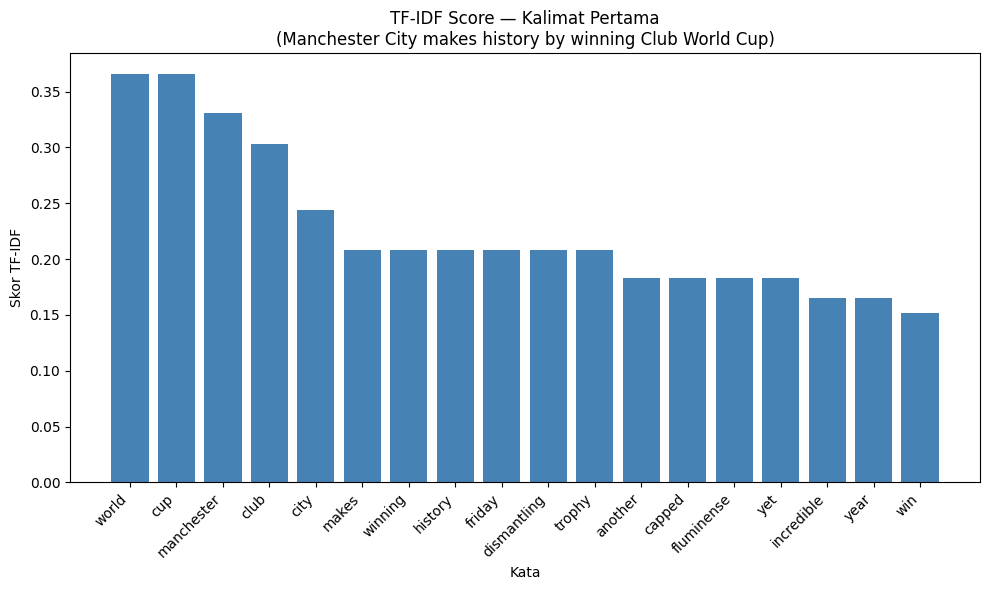

In [12]:
# VISUALISASI TF-IDF KALIMAT PERTAMA
plt.figure(figsize=(10, 6))
plt.bar(first_sentence_df['Feature'], first_sentence_df['TF-IDF'], color='steelblue')
plt.xlabel("Kata")
plt.ylabel("Skor TF-IDF")
plt.title("TF-IDF Score — Kalimat Pertama\n(Manchester City makes history by winning Club World Cup)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Hitung Sentence

In [14]:
# HITUNG RATA-RATA SKOR TF-IDF PER KALIMAT
sent_scores = []

print("Average TF-IDF Score per Kalimat")

for i in range(features.shape[0]):
    row = features[i]
    sum_score  = row.sum()
    word_count = len(row.data)
    avg_score  = sum_score / word_count if word_count > 0 else 0
    sent_scores.append(avg_score)

    print(f"Kalimat {i+1:2d} | Sum: {sum_score:.4f} | Words: {word_count:3d} | Avg: {avg_score:.4f}")

print("\nSemua Sentence Scores:")
print(sent_scores)

Average TF-IDF Score per Kalimat
Kalimat  1 | Sum: 4.0725 | Words:  18 | Avg: 0.2263
Kalimat  2 | Sum: 4.6474 | Words:  23 | Avg: 0.2021
Kalimat  3 | Sum: 3.7128 | Words:  14 | Avg: 0.2652
Kalimat  4 | Sum: 2.4348 | Words:   6 | Avg: 0.4058
Kalimat  5 | Sum: 3.7250 | Words:  14 | Avg: 0.2661
Kalimat  6 | Sum: 2.7350 | Words:   8 | Avg: 0.3419
Kalimat  7 | Sum: 2.8243 | Words:   8 | Avg: 0.3530
Kalimat  8 | Sum: 2.7947 | Words:   8 | Avg: 0.3493
Kalimat  9 | Sum: 3.4621 | Words:  12 | Avg: 0.2885
Kalimat 10 | Sum: 3.7357 | Words:  14 | Avg: 0.2668
Kalimat 11 | Sum: 3.9747 | Words:  16 | Avg: 0.2484
Kalimat 12 | Sum: 2.8243 | Words:   8 | Avg: 0.3530
Kalimat 13 | Sum: 3.3115 | Words:  11 | Avg: 0.3010
Kalimat 14 | Sum: 3.1227 | Words:  10 | Avg: 0.3123
Kalimat 15 | Sum: 1.7287 | Words:   3 | Avg: 0.5762
Kalimat 16 | Sum: 3.8273 | Words:  16 | Avg: 0.2392
Kalimat 17 | Sum: 3.9376 | Words:  16 | Avg: 0.2461
Kalimat 18 | Sum: 5.0261 | Words:  26 | Avg: 0.1933
Kalimat 19 | Sum: 3.1562 | Word

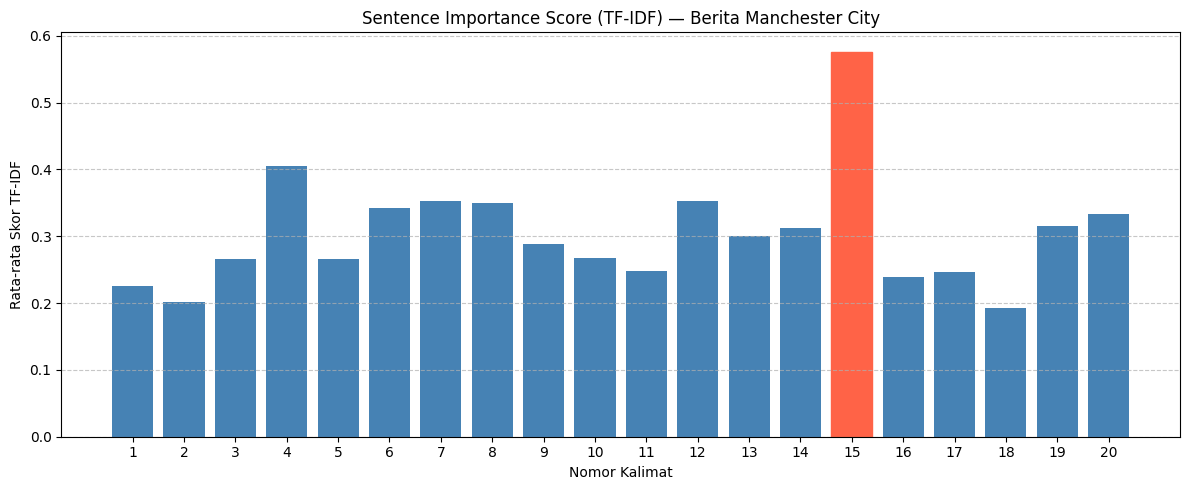


Penjelasan Histogram
Setiap kalimat dalam berita dihitung tingkat kepentingannya menggunakan metode TF-IDF (Term Frequency–Inverse Document Frequency). Nilai yang ditampilkan merupakan rata-rata skor TF-IDF tiap kalimat.

- Batang merah  → kalimat dengan skor tertinggi (paling informatif).
- Batang tinggi → kalimat mengandung kata spesifik & jarang muncul → kandidat kuat untuk ringkasan.
- Batang rendah → kalimat didominasi kata umum / informasi pendukung.


In [15]:
# VISUALISASI SENTENCE SCORE
plt.figure(figsize=(12, 5))
bars = plt.bar(range(1, len(sent_scores)+1), sent_scores, color='steelblue')

# Highlight bar tertinggi
max_idx = sent_scores.index(max(sent_scores))
bars[max_idx].set_color('tomato')

plt.xlabel("Nomor Kalimat")
plt.ylabel("Rata-rata Skor TF-IDF")
plt.title("Sentence Importance Score (TF-IDF) — Berita Manchester City")
plt.xticks(range(1, len(sent_scores)+1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nPenjelasan Histogram")
print(
    "Setiap kalimat dalam berita dihitung tingkat kepentingannya menggunakan "
    "metode TF-IDF (Term Frequency\u2013Inverse Document Frequency). "
    "Nilai yang ditampilkan merupakan rata-rata skor TF-IDF tiap kalimat."
)
print(
    "\n- Batang merah  \u2192 kalimat dengan skor tertinggi (paling informatif)."
)
print(
    "- Batang tinggi \u2192 kalimat mengandung kata spesifik & jarang muncul \u2192 kandidat kuat untuk ringkasan."
)
print(
    "- Batang rendah \u2192 kalimat didominasi kata umum / informasi pendukung."
)

## 6. Define Threshold

In [17]:
# THRESHOLD = RATA-RATA SEMUA SENTENCE SCORES
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print("Threshold")
print(f"Threshold (Rata-rata Sentence Score): {threshold:.6f}")
print(f"\nKalimat yang skornya >= {threshold:.4f} akan masuk ke ringkasan.")

Threshold
Threshold (Rata-rata Sentence Score): 0.304166

Kalimat yang skornya >= 0.3042 akan masuk ke ringkasan.


In [19]:
# CONTOH MANUAL: TF-IDF KATA 'city' PER KALIMAT

cleaned_lower = [s.lower() for s in sent_token]

def calculate_tf(term, document):
    words = word_tokenize(document)
    return words.count(term) / len(words) if words else 0

def calculate_idf(term, documents):
    doc_count = sum(1 for doc in documents if term in word_tokenize(doc))
    return math.log(len(documents) / doc_count) if doc_count > 0 else 0

term = "city"
idf_value = calculate_idf(term, cleaned_lower)
tfidf_per_sent = {}

for i, doc in enumerate(cleaned_lower):
    tf = calculate_tf(term, doc)
    tfidf_per_sent[f"Kalimat {i+1}"] = tf * idf_value

print(f"TF-IDF Manual untuk kata '{term}'")
for k, v in tfidf_per_sent.items():
    print(f"{k}: {v:.4f}")
print(f"\nIDF('{term}'): {idf_value:.4f}")

TF-IDF Manual untuk kata 'city'
Kalimat 1: 0.0636
Kalimat 2: 0.0000
Kalimat 3: 0.0456
Kalimat 4: 0.0000
Kalimat 5: 0.0000
Kalimat 6: 0.0000
Kalimat 7: 0.0000
Kalimat 8: 0.0477
Kalimat 9: 0.0000
Kalimat 10: 0.0000
Kalimat 11: 0.0350
Kalimat 12: 0.0000
Kalimat 13: 0.0000
Kalimat 14: 0.0456
Kalimat 15: 0.0000
Kalimat 16: 0.0269
Kalimat 17: 0.0000
Kalimat 18: 0.0175
Kalimat 19: 0.0000
Kalimat 20: 0.0000

IDF('city'): 1.0498


## 7. Generate Summary

In [20]:
# AMBIL KALIMAT DI ATAS THRESHOLD
final_summ = ""

print(f"Threshold: {threshold:.4f}")
print("\nKalimat yang Masuk Ringkasan")

for index, score in enumerate(sent_scores):
    if score >= threshold:
        final_summ += " " + sent_token[index]
        print(f"[{index+1}] (skor={score:.4f}) {sent_token[index]}")

print("\n" + "="*60)
print("HASIL RINGKASAN AKHIR")
print("="*60)
print(final_summ.strip())

Threshold: 0.3042

Kalimat yang Masuk Ringkasan
[4] (skor=0.4058) “We’ve shown over the past 12 months we are the best team in the world.
[6] (skor=0.3419) “To win these five trophies – for me, the five biggest prizes available to us – is incredible.
[7] (skor=0.3530) I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players.
[8] (skor=0.3493) I couldn’t ask for better teammates.”

It took just 40 seconds for Manchester City to take the lead.
[12] (skor=0.3530) Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.
[14] (skor=0.3123) City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year.
[15] (skor=0.5762) “As a manager it is what I am most proud of; that we are always there.
[19] (skor=0.3156) The champion heads back to England where it faces a tough title defence in the Premier League.
[20] (skor=0.3331) It currently sit

## 8. Summarization Result

In [21]:
# TAMPILKAN RINGKASAN FINAL
print("RINGKASAN BERITA MANCHESTER CITY")
print(final_summ.strip())

RINGKASAN BERITA MANCHESTER CITY
“We’ve shown over the past 12 months we are the best team in the world. “To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. I couldn’t ask for better teammates.”

It took just 40 seconds for Manchester City to take the lead. Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range. City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year. “As a manager it is what I am most proud of; that we are always there. The champion heads back to England where it faces a tough title defence in the Premier League. It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.
